# Enviroment Setup

In [16]:
!pip install prophet

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# !!! ACTION REQUIRED !!! - update paths for your project structure

DRIVE_PATH = '/content/drive/MyDrive/DP'

DATA_DIR = f'{DRIVE_PATH}/02_processed_data'
RES_DIR = f'{DRIVE_PATH}/05_prediction_results'
VIS_DIR = f'{DRIVE_PATH}/03_visualizations/Experiments/PROPHET'

# Processed Data

In [19]:
DATASETS = {
    'Boralesgamuwa': {
        'file': 'boralasgamuwa_processed.csv',
        'label': 'Boralesgamuwa UC (Sri Lanka)',
        'code': 'bo',
        'number': '1'
    },
    'Dehiwala': {
        'file': 'dehiwala_processed.csv',
        'label': 'Dehiwala MC (Sri Lanka)',
        'code': 'de',
        'number': '2'
    },
    'Homagama': {
        'file': 'homagama_processed.csv',
        'label': 'Homagama PS (Sri Lanka)',
        'code': 'ho',
        'number': '3'
    },
    'Moratuwa': {
        'file': 'moratuwa_processed.csv',
        'label': 'Moratuwa MC (Sri Lanka)',
        'code': 'mo',
        'number': '4'
    },
    'Austin': {
        'file': 'austin_processed.csv',
        'label': 'Austin TX (USA)',
        'code': 'au',
        'number': '5'
    },
    'Ballarat': {
        'file': 'ballarat_processed.csv',
        'label': 'Ballarat (Australia)',
        'code': 'ba',
        'number': '6'
    }
}

In [20]:
FEATURES = [
    'is_weekend', 'is_holiday', 'tavg', 'prcp',
    'is_after_weekend', 'is_after_holiday', 'is_after_gap',
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30',
]

TARGET = 'total_tonnes'

# Model Definition - Prophet

In [21]:
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error — robust to zero values."""
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 0
    if mask.sum() == 0:
        return float('nan')
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def run_prophet_prediction(df, dataset_name, dataset_code, dataset_number, features, split_days=90, n_splits=3, TARGET='total_tonnes', VIS_DIR='.'):
    """
    Train Prophet with rolling-origin validation.
    Plots are generated ONLY for the best split (lowest sMAPE).
    """
    print(f"\n{'='*100}")
    print(f"PROPHET PREDICTION — {dataset_name}")
    print(f"{'='*100}")

    df = df.sort_values('date').reset_index(drop=True)

    # filter out features that actually exist in the dataframe
    available_features = [f for f in features if f in df.columns and f != TARGET]
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        print(f"Note: Missing features (skipped): {missing_features}")

    df_prophet = df.copy()
    df_prophet = df_prophet.rename(columns={'date': 'ds', TARGET: 'y'})

    # drop rows where target is NaN
    df_valid = df_prophet.dropna(subset=['y']).reset_index(drop=True)
    print(f"Total rows: {len(df)}, Valid (non-NaN target): {len(df_valid)}")


    # ============================================================
    # ROLLING-ORIGIN VALIDATION
    # ============================================================
    split_results = []
    total_needed = split_days * n_splits

    if len(df_valid) < total_needed + 100:
        print(f"WARNING: Not enough data for {n_splits} splits of {split_days} days. Reducing to 2 splits.")
        n_splits = 2

    print(f"\nRolling-origin validation: {n_splits} splits of {split_days} days each")

    best_smape = float('inf')
    best_split_data = None

    for split_idx in range(n_splits):
        offset = (n_splits - 1 - split_idx) * split_days

        if offset == 0:
            train = df_valid.iloc[:-split_days].copy()
            test = df_valid.iloc[-split_days:].copy()
        else:
            train = df_valid.iloc[:-(offset + split_days)].copy()
            test = df_valid.iloc[-(offset + split_days):-offset].copy()

        print(f"\n--- Split {split_idx+1}/{n_splits} ---")
        print(f"Train: {len(train)} days ({train['ds'].min().date()} → {train['ds'].max().date()})")
        print(f"Test:  {len(test)} days ({test['ds'].min().date()} → {test['ds'].max().date()})")

        # initialize Prophet model
        m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)

        # add additional regressors
        for feature in available_features:
            # fill NaNs in regressors
            if train[feature].isna().any():
                train[feature] = train[feature].ffill().bfill()
            if test[feature].isna().any():
                test[feature] = test[feature].ffill().bfill()

            m.add_regressor(feature)

        # fit model
        m.fit(train)

        # forecast
        forecast = m.predict(test)

        y_true = test['y'].values
        y_pred = forecast['yhat'].values

        # clip negatives to 0
        y_pred = np.clip(y_pred, 0, None)

        # metrics
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        smape_val = smape(y_true, y_pred)

        split_results.append({'mae': mae, 'rmse': rmse, 'smape': smape_val})
        print(f"MAE: {mae:.2f}t | RMSE: {rmse:.2f}t | sMAPE: {smape_val:.2f}%")

        # track the best split
        if smape_val < best_smape:
            best_smape = smape_val
            best_split_data = {
                'split_idx': split_idx + 1,
                'train': train,
                'test': test,
                'y_true': y_true,
                'y_pred': y_pred,
                'mae': mae,
                'rmse': rmse,
                'smape': smape_val
            }


    # ============================================================
    # AVERAGE METRICS ACROSS SPLITS
    # ============================================================
    avg_mae = np.mean([r['mae'] for r in split_results])
    avg_rmse = np.mean([r['rmse'] for r in split_results])
    avg_smape = np.mean([r['smape'] for r in split_results])

    print(f"\n--- AVERAGE ACROSS {n_splits} SPLITS ---")
    print(f"MAE:   {avg_mae:.2f} tonnes")
    print(f"RMSE:  {avg_rmse:.2f} tonnes")
    print(f"sMAPE: {avg_smape:.2f}%")
    print(f"Best split was Split {best_split_data['split_idx']} (sMAPE: {best_split_data['smape']:.2f}%)")


    # ============================================================
    # PLOT — BEST SPLIT ONLY
    # ============================================================
    train_plot = best_split_data['train']
    test_plot = best_split_data['test']
    y_true_plot = best_split_data['y_true']
    y_pred_plot = best_split_data['y_pred']


    # --- Plot 5X1: Actual vs Predicted (test period) ---
    fig, ax = plt.subplots(figsize=(16, 6))

    context = train_plot.iloc[-30:]
    ax.plot(context['ds'], context['y'], color='steelblue', linewidth=1, label='Training Data (last 30 days)')
    ax.plot(test_plot['ds'], y_true_plot, color='steelblue', linewidth=1.5, label='Actual (Test)')
    ax.plot(test_plot['ds'], y_pred_plot, color='red', linewidth=1.5, linestyle='--', label='Prophet Forecast')
    ax.axvline(x=test_plot['ds'].iloc[0], color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')

    ax.set_title(f"Prophet Forecast vs Actual — {dataset_name} (Best Split: #{best_split_data['split_idx']})", fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.set_xlabel('Date')
    ax.legend(fontsize=10)

    ax.text(0.02, 0.95, f"Best Split Metrics:\nMAE: {best_split_data['mae']:.2f}t\nRMSE: {best_split_data['rmse']:.2f}t\nsMAPE: {best_split_data['smape']:.1f}%",
            transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.savefig(os.path.join(VIS_DIR, f'5{dataset_number}1_prophet_forecast_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # --- Plot 5X2: Zoom on first 30 days ---
    fig, ax = plt.subplots(figsize=(14, 5))
    zoom_days = min(30, split_days)
    ax.plot(test_plot['ds'].iloc[:zoom_days], y_true_plot[:zoom_days], color='steelblue', linewidth=2, marker='o', markersize=3, label='Actual')
    ax.plot(test_plot['ds'].iloc[:zoom_days], y_pred_plot[:zoom_days], color='red', linewidth=2, marker='s', markersize=3, linestyle='--', label='Prophet')
    ax.set_title(f"Prophet Forecast Zoom — {dataset_name} (Best Split: #{best_split_data['split_idx']})", fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(VIS_DIR, f'5{dataset_number}2_prophet_forecast_zoom_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'dataset': dataset_name,
        'model': 'Prophet',
        'mae': round(avg_mae, 2),
        'rmse': round(avg_rmse, 2),
        'smape': round(avg_smape, 2),
        'n_splits': n_splits,
        'split_days': split_days,
        'split_details': split_results
    }

# Model Prediction -  Prophet


PROPHET PREDICTION — Boralesgamuwa UC (Sri Lanka)
Total rows: 2527, Valid (non-NaN target): 2387

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 2117 days (2012-01-31 → 2018-03-26)
Test:  90 days (2018-03-28 → 2018-06-28)
MAE: 8.11t | RMSE: 10.04t | sMAPE: 30.35%

--- Split 2/3 ---
Train: 2207 days (2012-01-31 → 2018-06-28)
Test:  90 days (2018-06-29 → 2018-09-29)
MAE: 5.73t | RMSE: 8.02t | sMAPE: 24.24%

--- Split 3/3 ---
Train: 2297 days (2012-01-31 → 2018-09-29)
Test:  90 days (2018-09-30 → 2018-12-31)
MAE: 6.49t | RMSE: 8.63t | sMAPE: 25.52%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   6.78 tonnes
RMSE:  8.90 tonnes
sMAPE: 26.70%
Best split was Split 2 (sMAPE: 24.24%)


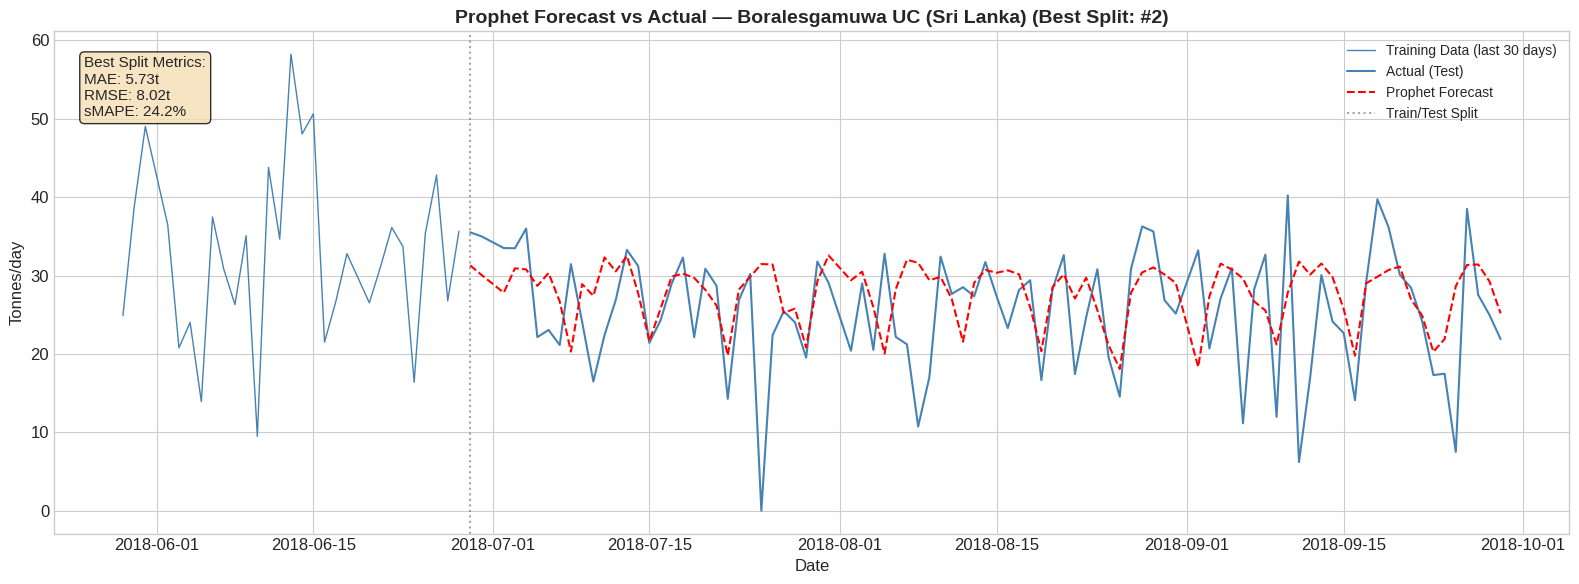

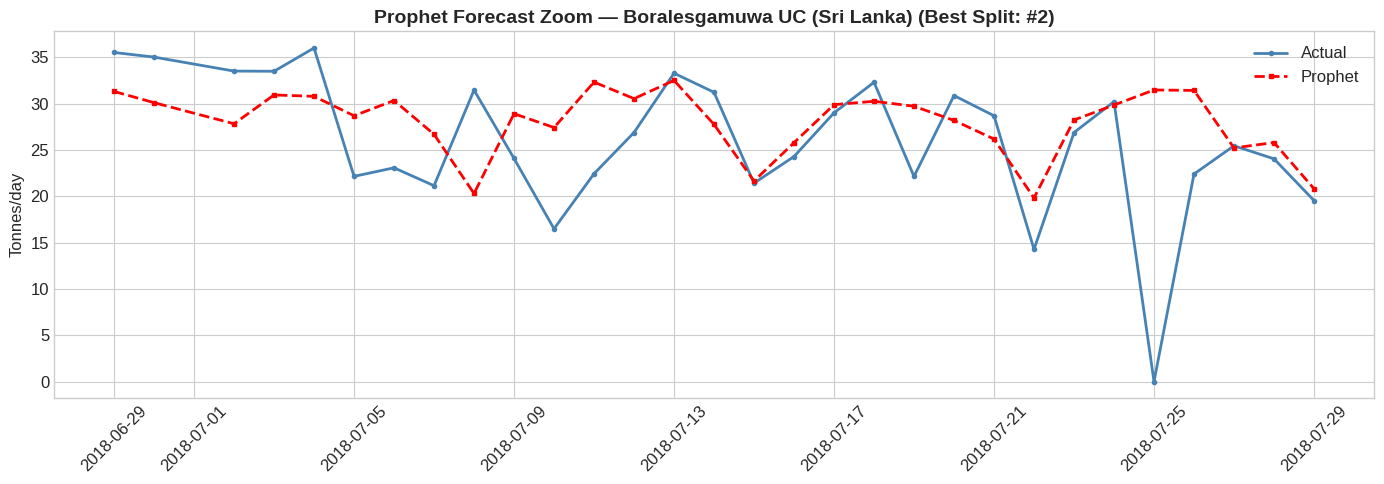


PROPHET PREDICTION — Dehiwala MC (Sri Lanka)
Total rows: 1431, Valid (non-NaN target): 1403

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 1133 days (2012-01-31 → 2015-03-28)
Test:  90 days (2015-03-29 → 2015-07-01)
MAE: 26.97t | RMSE: 33.37t | sMAPE: 18.88%

--- Split 2/3 ---
Train: 1223 days (2012-01-31 → 2015-07-01)
Test:  90 days (2015-07-02 → 2015-09-29)
MAE: 37.13t | RMSE: 50.05t | sMAPE: 31.90%

--- Split 3/3 ---
Train: 1313 days (2012-01-31 → 2015-09-29)
Test:  90 days (2015-09-30 → 2015-12-31)
MAE: 26.87t | RMSE: 38.41t | sMAPE: 20.79%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   30.32 tonnes
RMSE:  40.61 tonnes
sMAPE: 23.86%
Best split was Split 1 (sMAPE: 18.88%)


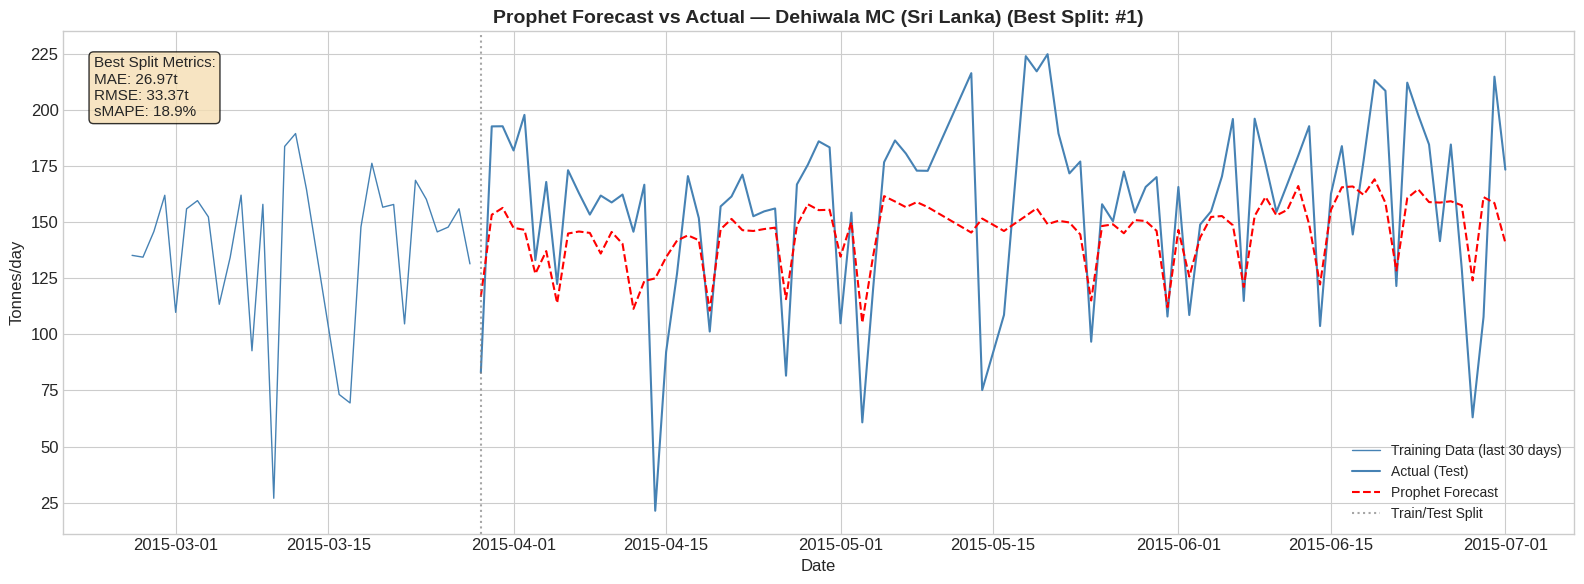

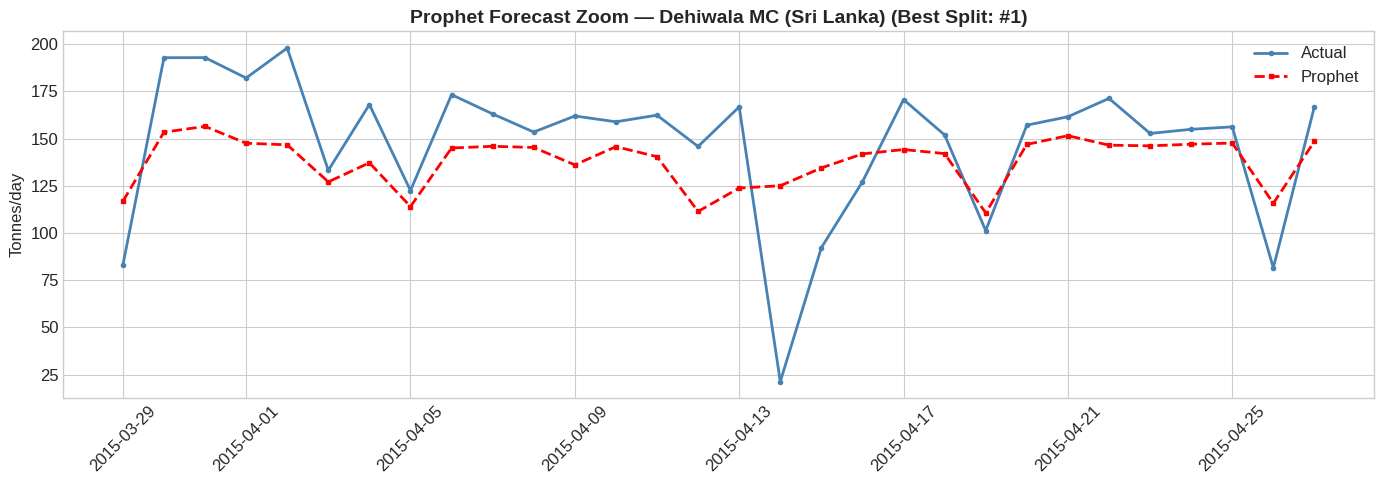


PROPHET PREDICTION — Homagama PS (Sri Lanka)
Total rows: 2526, Valid (non-NaN target): 2038

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 1768 days (2012-02-02 → 2018-03-21)
Test:  90 days (2018-03-22 → 2018-06-25)
MAE: 12.55t | RMSE: 16.27t | sMAPE: 36.30%

--- Split 2/3 ---
Train: 1858 days (2012-02-02 → 2018-06-25)
Test:  90 days (2018-06-26 → 2018-09-29)
MAE: 9.30t | RMSE: 11.91t | sMAPE: 30.22%

--- Split 3/3 ---
Train: 1948 days (2012-02-02 → 2018-09-29)
Test:  90 days (2018-09-30 → 2018-12-31)
MAE: 10.70t | RMSE: 14.29t | sMAPE: 30.58%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   10.85 tonnes
RMSE:  14.16 tonnes
sMAPE: 32.37%
Best split was Split 2 (sMAPE: 30.22%)


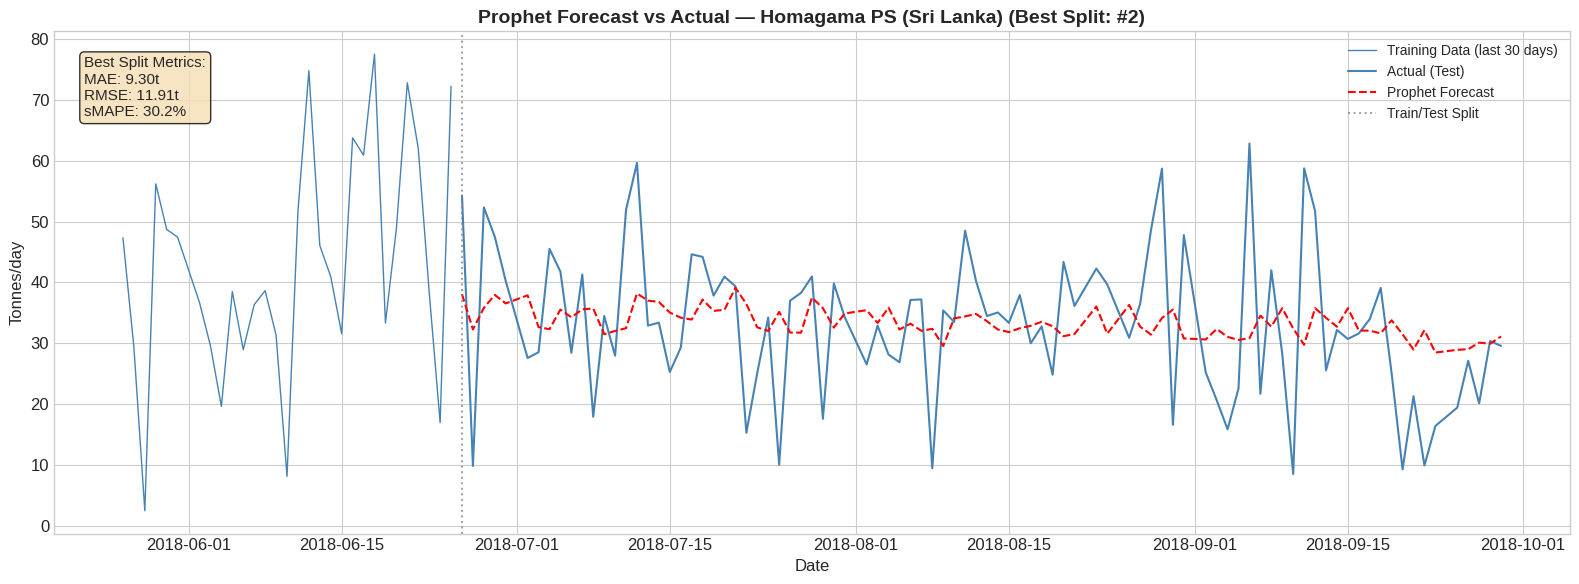

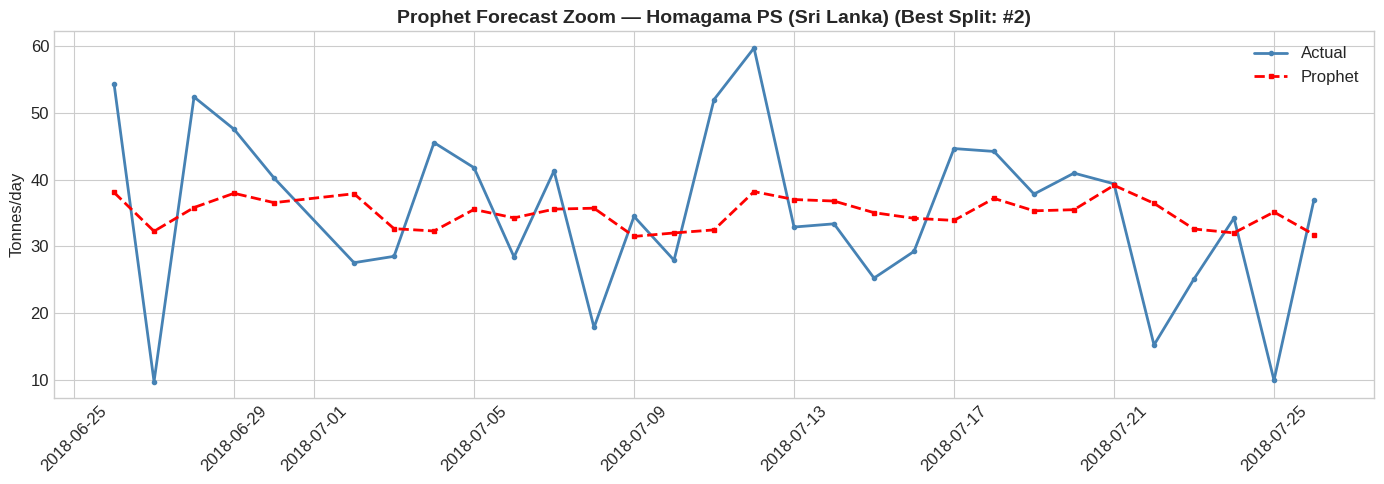


PROPHET PREDICTION — Moratuwa MC (Sri Lanka)
Total rows: 1411, Valid (non-NaN target): 1278

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 1008 days (2015-01-31 → 2018-02-26)
Test:  90 days (2018-02-27 → 2018-06-03)
MAE: 15.25t | RMSE: 21.43t | sMAPE: 23.00%

--- Split 2/3 ---
Train: 1098 days (2015-01-31 → 2018-06-03)
Test:  90 days (2018-06-04 → 2018-09-08)
MAE: 18.95t | RMSE: 23.88t | sMAPE: 26.55%

--- Split 3/3 ---
Train: 1188 days (2015-01-31 → 2018-09-08)
Test:  90 days (2018-09-09 → 2018-12-11)
MAE: 19.29t | RMSE: 25.95t | sMAPE: 28.65%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   17.83 tonnes
RMSE:  23.75 tonnes
sMAPE: 26.07%
Best split was Split 1 (sMAPE: 23.00%)


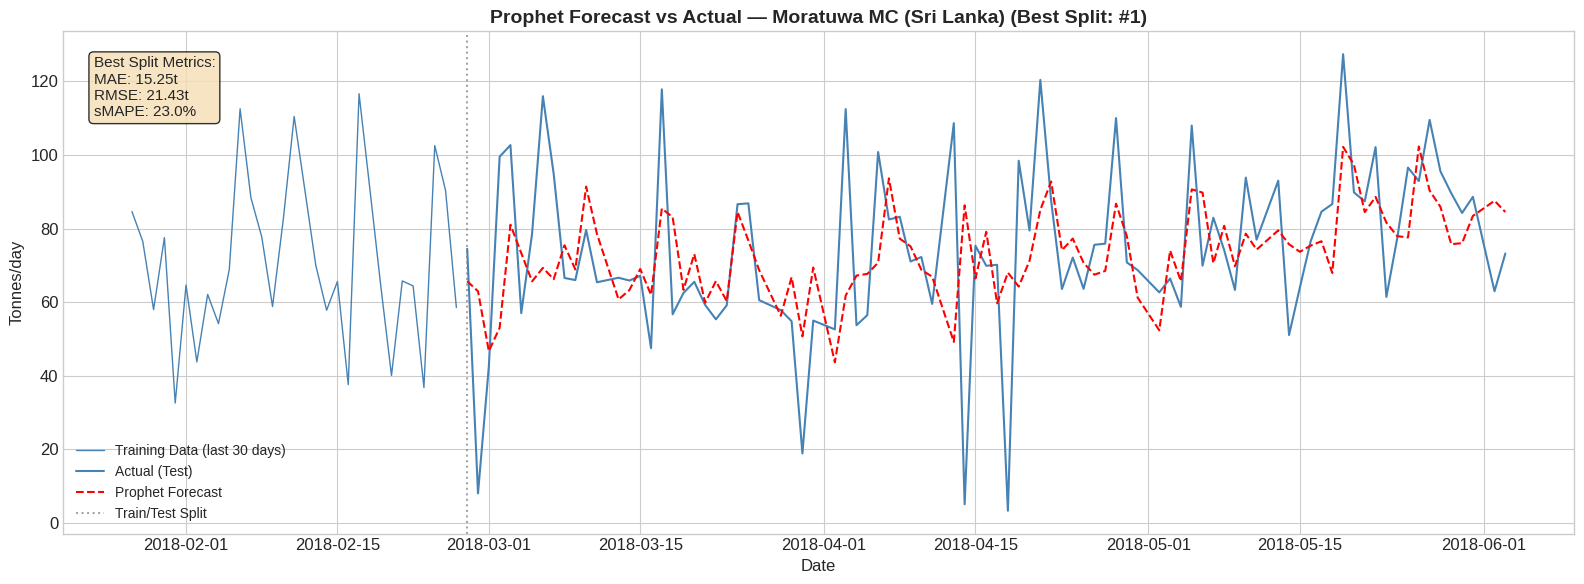

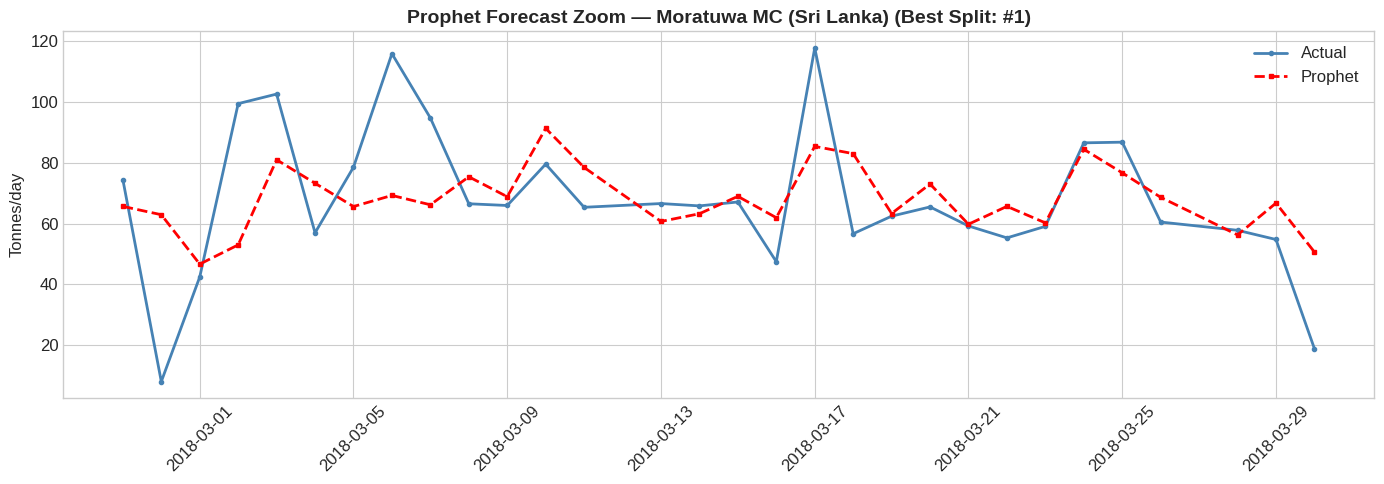


PROPHET PREDICTION — Austin TX (USA)
Total rows: 5813, Valid (non-NaN target): 5803

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 5533 days (2005-02-01 → 2020-04-04)
Test:  90 days (2020-04-05 → 2020-07-03)
MAE: 158.91t | RMSE: 210.37t | sMAPE: 51.65%

--- Split 2/3 ---
Train: 5623 days (2005-02-01 → 2020-07-03)
Test:  90 days (2020-07-04 → 2020-10-01)
MAE: 111.51t | RMSE: 142.01t | sMAPE: 49.94%

--- Split 3/3 ---
Train: 5713 days (2005-02-01 → 2020-10-01)
Test:  90 days (2020-10-02 → 2020-12-31)
MAE: 206.43t | RMSE: 365.25t | sMAPE: 53.39%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   158.95 tonnes
RMSE:  239.21 tonnes
sMAPE: 51.66%
Best split was Split 2 (sMAPE: 49.94%)


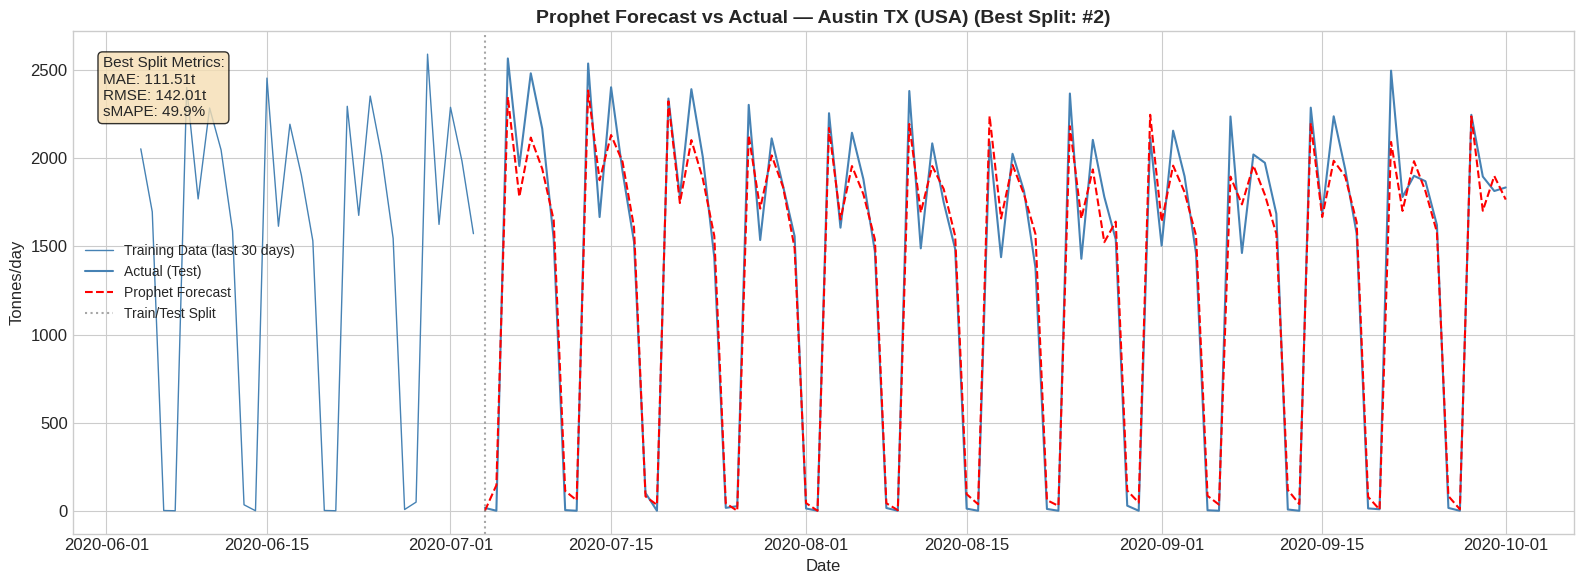

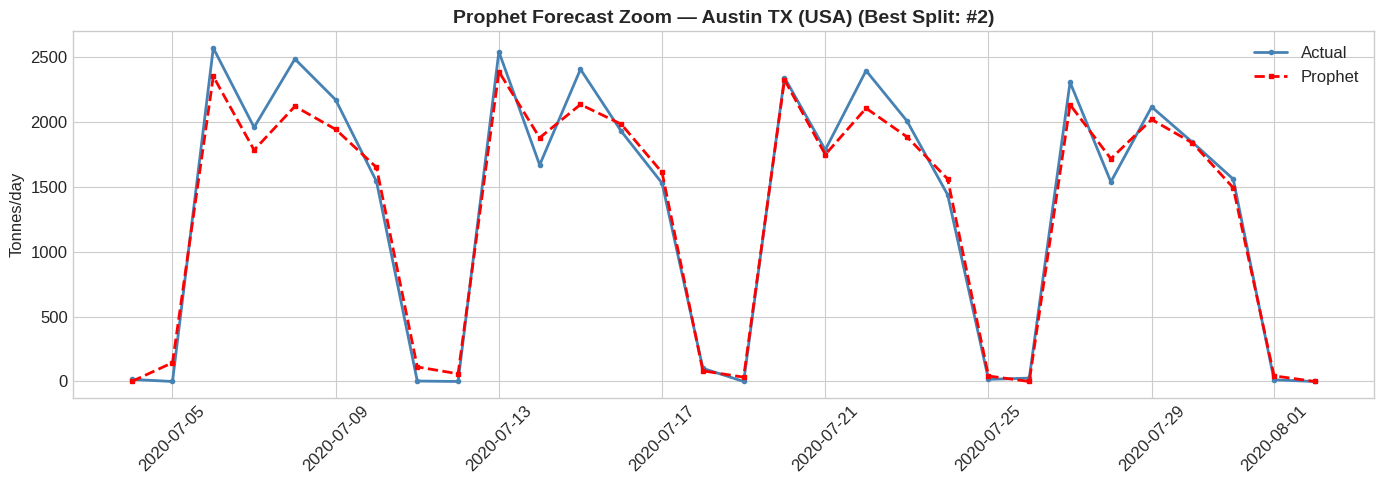


PROPHET PREDICTION — Ballarat (Australia)
Total rows: 4717, Valid (non-NaN target): 4703

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 4433 days (2001-02-01 → 2013-04-03)
Test:  90 days (2013-04-04 → 2013-07-02)
MAE: 7.85t | RMSE: 11.38t | sMAPE: 65.13%

--- Split 2/3 ---
Train: 4523 days (2001-02-01 → 2013-07-02)
Test:  90 days (2013-07-03 → 2013-10-01)
MAE: 8.70t | RMSE: 11.81t | sMAPE: 65.74%

--- Split 3/3 ---
Train: 4613 days (2001-02-01 → 2013-10-01)
Test:  90 days (2013-10-02 → 2013-12-31)
MAE: 9.63t | RMSE: 13.43t | sMAPE: 64.48%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   8.73 tonnes
RMSE:  12.21 tonnes
sMAPE: 65.12%
Best split was Split 3 (sMAPE: 64.48%)


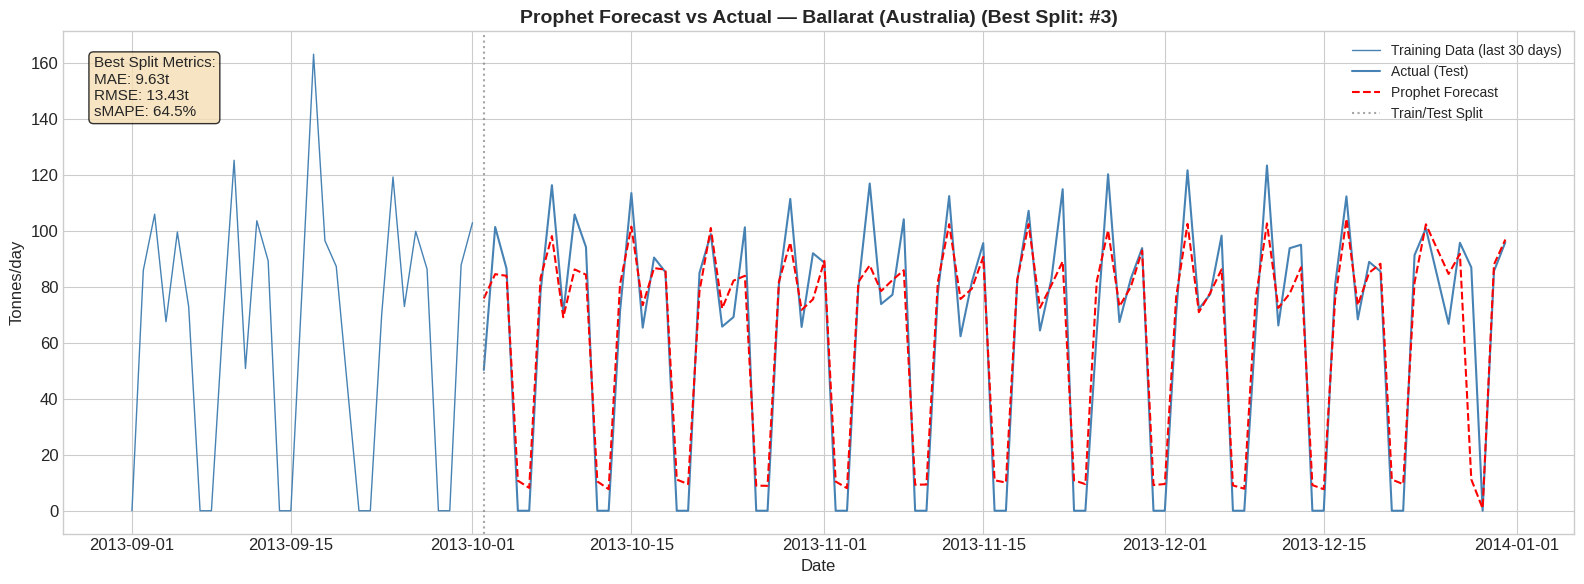

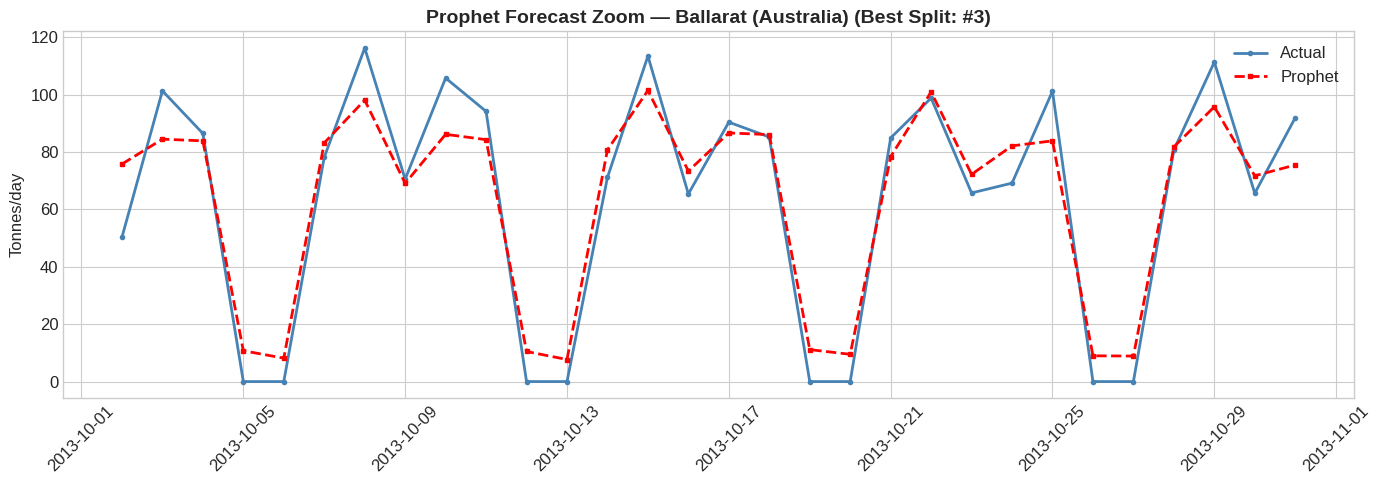

In [24]:
all_results = []

for name, config in DATASETS.items():
    filepath = os.path.join(DATA_DIR, config['file'])

    try:
        df = pd.read_csv(filepath)
        df['date'] = pd.to_datetime(df['date'])

        result = run_prophet_prediction(
            df = df,
            dataset_name = config['label'],
            dataset_code = config['code'],
            dataset_number = config['number'],
            features = FEATURES,
            split_days = 90,
            n_splits = 3,
            TARGET = TARGET,
            VIS_DIR = VIS_DIR
        )
        all_results.append(result)

    except Exception as e:
        print(f"\n{'='*100}")
        print(f"ERROR processing {name}: {e}")
        print(f"{'='*100}")
        import traceback
        traceback.print_exc()

# Prediction Summary

In [26]:
print("\n" + "=" * 100)
print("PROPHET RESULTS SUMMARY — ALL DATASETS")
print("=" * 100)

if len(all_results) > 0:
    results_df = pd.DataFrame(all_results)

    print(f"\nValidation: Rolling-origin with {all_results[0]['n_splits']} splits of {all_results[0]['split_days']} days")
    print(f"Metrics are AVERAGED across splits.")
    print(f"\n{'Dataset':<30s} | {'MAE (t)':>8s} | {'RMSE (t)':>9s} | {'sMAPE (%)':>9s}")
    print("-" * 65)

    for _, row in results_df.iterrows():
        print(f"{row['dataset']:<30s} | {row['mae']:>8.2f} | {row['rmse']:>9.2f} | {row['smape']:>8.2f}%")

    # Average
    print("-" * 65)
    print(f"{'AVERAGE':<30s} | {results_df['mae'].mean():>8.2f} | {results_df['rmse'].mean():>9.2f} | {results_df['smape'].mean():>8.2f}%")

    # Per-split detail
    print(f"\n--- Per-split details ---")
    for _, row in results_df.iterrows():
        print(f"\n{row['dataset']}:")
        for j, s in enumerate(row['split_details']):
            print(f"  Split {j+1}: MAE={s['mae']:.2f}t, RMSE={s['rmse']:.2f}t, sMAPE={s['smape']:.2f}%")


# save results
results_df.to_csv(os.path.join(RES_DIR, 'prophet_results.csv'), index=False)
print(f"\nResults saved to: {RES_DIR}/prophet_results.csv")


PROPHET RESULTS SUMMARY — ALL DATASETS

Validation: Rolling-origin with 3 splits of 90 days
Metrics are AVERAGED across splits.

Dataset                        |  MAE (t) |  RMSE (t) | sMAPE (%)
-----------------------------------------------------------------
Boralesgamuwa UC (Sri Lanka)   |     6.78 |      8.90 |    26.70%
Dehiwala MC (Sri Lanka)        |    30.32 |     40.61 |    23.86%
Homagama PS (Sri Lanka)        |    10.85 |     14.16 |    32.37%
Moratuwa MC (Sri Lanka)        |    17.83 |     23.75 |    26.07%
Austin TX (USA)                |   158.95 |    239.21 |    51.66%
Ballarat (Australia)           |     8.73 |     12.21 |    65.12%
-----------------------------------------------------------------
AVERAGE                        |    38.91 |     56.47 |    37.63%

--- Per-split details ---

Boralesgamuwa UC (Sri Lanka):
  Split 1: MAE=8.11t, RMSE=10.04t, sMAPE=30.35%
  Split 2: MAE=5.73t, RMSE=8.02t, sMAPE=24.24%
  Split 3: MAE=6.49t, RMSE=8.63t, sMAPE=25.52%

Dehiwala 

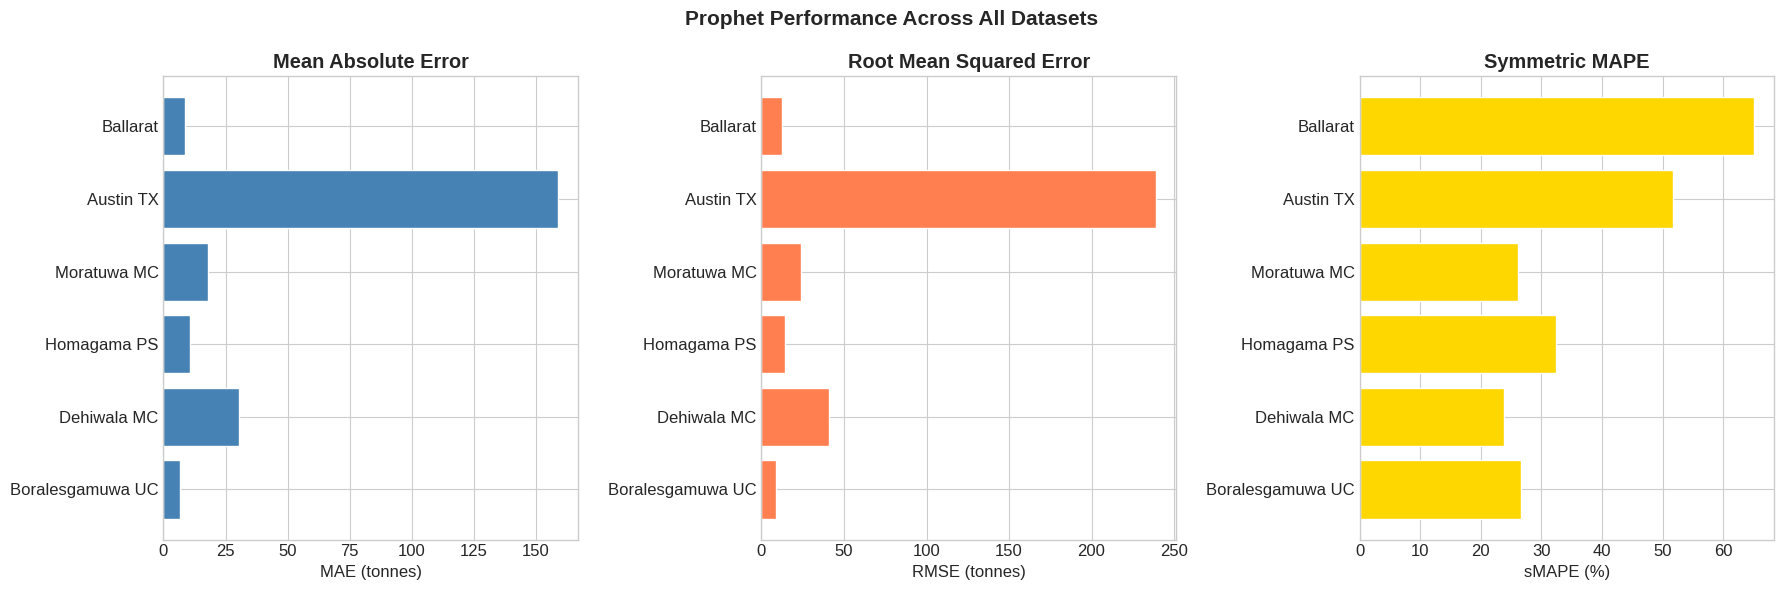

In [27]:
# --- Plot 501: Prophet Performance ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

short_names = [r['dataset'].split('(')[0].strip() for r in all_results]

# MAE
axes[0].barh(short_names, results_df['mae'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('MAE (tonnes)')
axes[0].set_title('Mean Absolute Error', fontweight='bold')

# RMSE
axes[1].barh(short_names, results_df['rmse'], color='coral', edgecolor='white')
axes[1].set_xlabel('RMSE (tonnes)')
axes[1].set_title('Root Mean Squared Error', fontweight='bold')

# sMAPE
axes[2].barh(short_names, results_df['smape'], color='gold', edgecolor='white')
axes[2].set_xlabel('sMAPE (%)')
axes[2].set_title('Symmetric MAPE', fontweight='bold')

plt.suptitle('Prophet Performance Across All Datasets', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '501_prophet_comparison_all.png'), dpi=150, bbox_inches='tight')
plt.show()